<a href="https://colab.research.google.com/github/Ellenkyei/Classification-and-Regression/blob/main/3_000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LOGISTIC REGRESSION WITH BOOLEAN OR WORDS AS CLASSES OF THE TARGET OR DEPENDENT VARIABLE.**

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
#loading dataset
student_records = pd.read_csv(r'StudentPerformanceFactors.csv')

In [ ]:
student_records['pass'] = student_records['Exam_Score'].apply(lambda x: 'Pass' if x >= 70 else 'Fail')
student_records.head()


# Alternative using numpy.where
#student_records['pass_alternative'] = np.where(student_records['Exam_Score'] >= 70, 'Pass', 'Fail')



,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,pass
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Fail
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Fail
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Pass
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Pass
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,Pass


In [ ]:
#defining my variables
x = student_records.iloc[ : , [0,1]]
y = student_records.iloc[ : , -1]

In [ ]:
#spliting the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


#x_train = train_test_split(x,test_size=0.2, random_state= 42)
#x_test = train_test_split(x,test_size=0.2, random_state= 42)
#y_train = train_test_split(y,test_size=0.2, random_state= 42)
#y_test = train_test_split(y,test_size=0.2, random_state= 42)

In [ ]:
#printing the shape
#x_train.shape
#x_test.shape
#y_train.shape
#y_test.shape
#print(f'The Shape of x_train is {}')

In [ ]:
lo_model = LogisticRegression(multi_class='auto')
lo_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='auto')

**Evaluating The Model.**

For evaluating a logistic regression model (which is a classification model), several metrics can be used. Some of the most common ones include:



*   Accuracy
*   Precision
*   Recall (Sensitivity)
*   F1 Score
*   ROC Curve and AUC (Area Under the Curve)
*   Confusion Matrix






In [ ]:
y_predict = lo_model.predict(x_test)

In [ ]:
lo_model.predict([[42,70]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Pass'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy:.4f}")

# Calculate Precision
precision = precision_score(y_test, y_predict, pos_label='Pass')
print(f"Precision: {precision:.4f}")

Accuracy: 0.8911
Precision: 0.8312


In [ ]:
# Calculate Recall
recall = recall_score(y_test, y_predict, pos_label='Pass')
print(f"Recall: {recall:.4f}")

# Calculate F1-Score
f1 = f1_score(y_test, y_predict, pos_label='Pass')
print(f"F1-Score: {f1:.4f}")


Recall: 0.7356
F1-Score: 0.7805


**Confusion Matrix:**

A table that describes the performance of a classification model on a set of test data for which the true values are known. It shows the counts of true positives, true negatives, false positives, and false negatives.

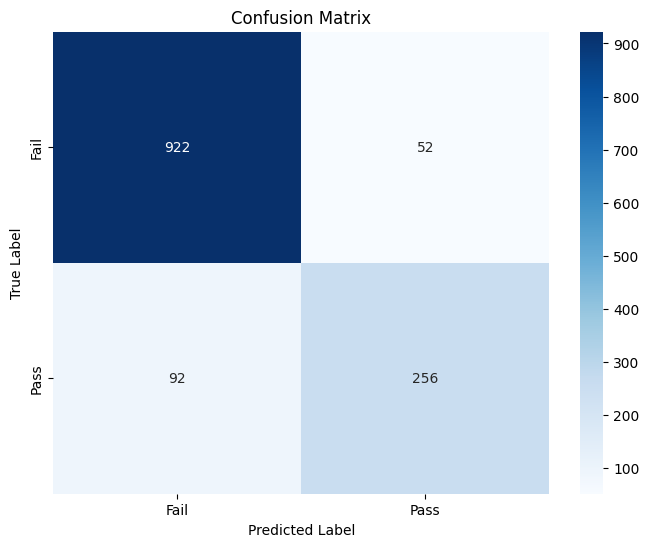

In [ ]:
# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_predict, labels=['Fail', 'Pass'])

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Explanation of ROC Curve and Confusion Matrix

**ROC Curve and AUC Score:**

The **Receiver Operating Characteristic (ROC) curve** is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

*   **True Positive Rate (TPR)**: Also known as Recall or Sensitivity, it's the proportion of actual positive cases that were correctly identified.
*   **False Positive Rate (FPR)**: The proportion of actual negative cases that were incorrectly identified as positive.

The **Area Under the Curve (AUC)** measures the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1 represents a perfect classifier, and an AUC of 0.5 represents a classifier with no better performance than random guessing.


**Confusion Matrix:**

After calculating, the confusion matrix will show:

*   **True Negatives (TN)**: The number of 'Fail' students correctly predicted as 'Fail'. (Top-left cell)
*   **False Positives (FP)**: The number of 'Fail' students incorrectly predicted as 'Pass'. (Top-right cell)
*   **False Negatives (FN)**: The number of 'Pass' students incorrectly predicted as 'Fail'. (Bottom-left cell)
*   **True Positives (TP)**: The number of 'Pass' students correctly predicted as 'Pass'. (Bottom-right cell)

This matrix gives a detailed breakdown of correct and incorrect predictions for each class, providing insights into where the model is performing well and where it's struggling.

In [ ]:
# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_test, lo_model.predict_proba(x_test)[:, 1])
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lo_model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()


ROC AUC Score: 0.9321


ValueError: y_true takes value in {'Fail', 'Pass'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

**Confusion Matrix:**

A table that describes the performance of a classification model on a set of test data for which the true values are known. It shows the counts of true positives, true negatives, false positives, and false negatives.